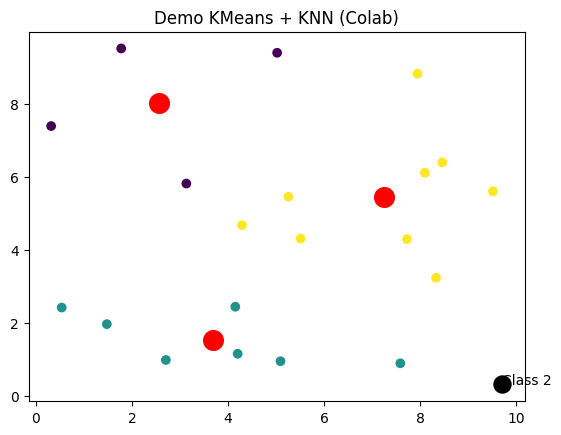

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ====== KMEANS ======
def kmeans(X, k=3):
    centers = X[np.random.choice(len(X), k, replace=False)]

    while True:
        distances = cdist(X, centers)
        labels = np.argmin(distances, axis=1)

        new_centers = np.array([X[labels == i].mean(axis=0) for i in range(k)])

        if np.allclose(centers, new_centers):
            break

        centers = new_centers

    return centers, labels

# ====== KNN ======
def knn(X, y, point, k=3):
    distances = np.sqrt(((X - point)**2).sum(axis=1))
    idx = np.argsort(distances)[:k]
    nearest_labels = y[idx]

    values, counts = np.unique(nearest_labels, return_counts=True)
    return values[np.argmax(counts)]

# ====== DỮ LIỆU GIẢ LẬP ======
points = np.random.rand(20, 2) * 10

# ====== KMEANS ======
centers, labels = kmeans(points, 3)

plt.scatter(points[:,0], points[:,1], c=labels)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200)

# ====== KNN ======
test_point = np.random.rand(2) * 10
pred = knn(points, labels, test_point, 3)

plt.scatter(test_point[0], test_point[1], c='black', s=150)
plt.text(test_point[0], test_point[1], f"Class {pred}")

plt.title("Demo KMeans + KNN (Colab)")
plt.show()